# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_auc_score, roc_curve
from sklearn.mixture import GaussianMixture

seed = 31287


In [3]:
data = pd.read_csv('data/banknote_authentication.csv' )

In [4]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [5]:
features = list(data.columns[:-1])
target = 'counterfeit'

data_train, data_test = train_test_split(
    data,
    test_size=0.2,
    shuffle=True,
    stratify=data[target],
    random_state=seed,
)

X_train = data_train[features].to_numpy()
y_train = data_train[target].to_numpy()
X_test = data_test[features].to_numpy()
y_test = data_test[target].to_numpy()


## Problem 

### A.

Perform the Quadratic Discriminant Analysis on this set. Calculate the confusion matrix, AUC score and plot the ROC curve. 

QDA confusion matrix, normalized by true class:
[[0.81967213 0.18032787]
 [0.28571429 0.71428571]]
QDA ROC AUC: 0.8754


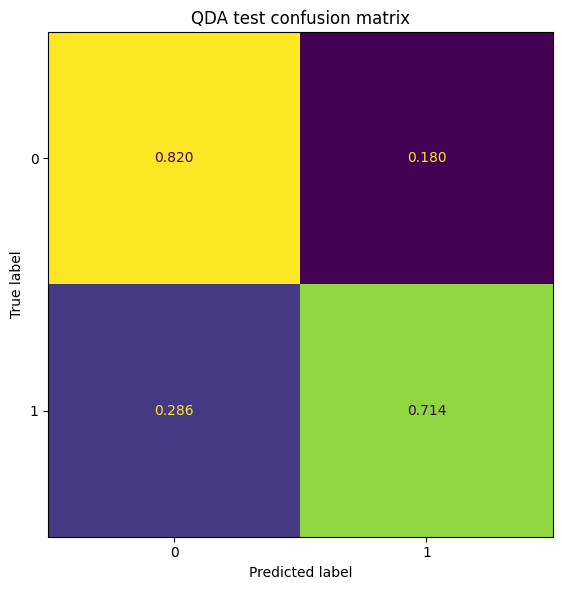

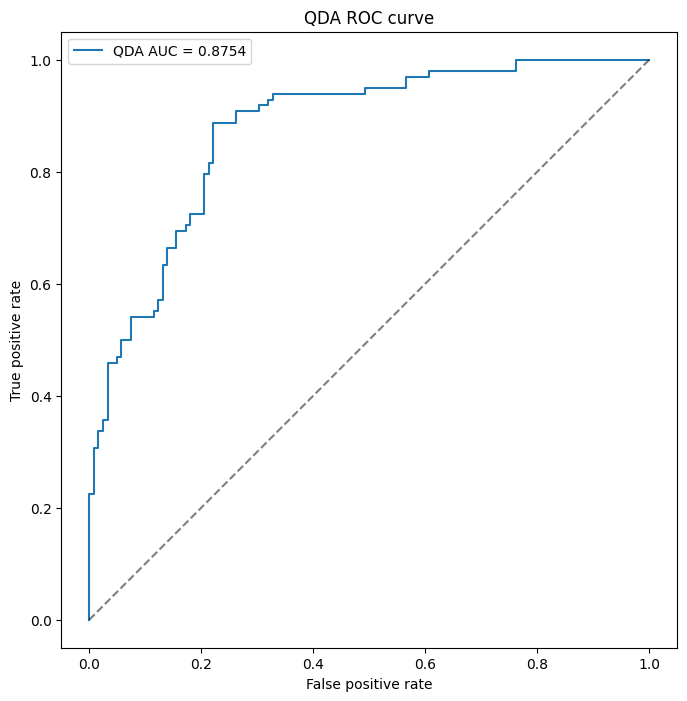

In [6]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train, y_train)

qda_test_proba = qda.predict_proba(X_test)[:, 1]
qda_test_pred = qda.predict(X_test)
qda_auc = roc_auc_score(y_test, qda_test_proba)
qda_fprs, qda_tprs, qda_thds = roc_curve(y_test, qda_test_proba)

print('QDA confusion matrix, normalized by true class:')
print(confusion_matrix(y_test, qda_test_pred, normalize='true'))
print(f'QDA ROC AUC: {qda_auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, qda_test_pred, normalize='true', values_format='.3f', ax=ax, colorbar=False
)
ax.set_title('QDA test confusion matrix')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(qda_fprs, qda_tprs, label=f'QDA AUC = {qda_auc:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('QDA ROC curve')
ax.legend()
plt.show()


### B.

Perform Gaussian Mixture Discriminant Analysis on this set as described in the `gaussian_mixture_model_EM_algorithm` notebook. Use two components for positives and two components for negatives. Calculate the confusion matrix, AUC score and plot the ROC curve. 

GMDA confusion matrix, normalized by true class:
[[0.91803279 0.08196721]
 [0.2755102  0.7244898 ]]
GMDA ROC AUC: 0.9404


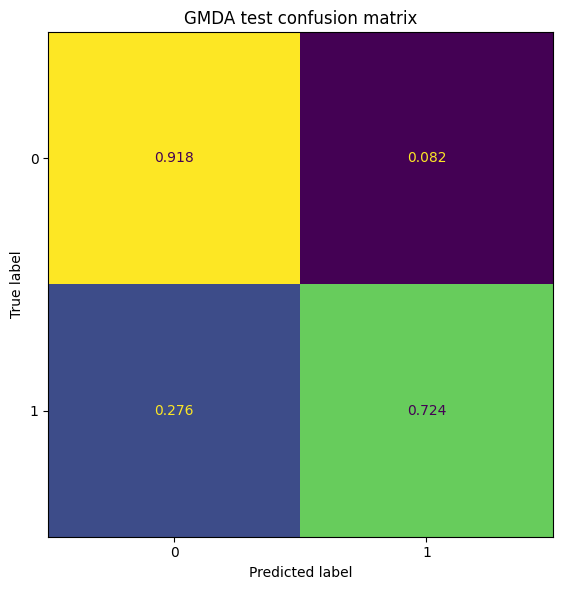

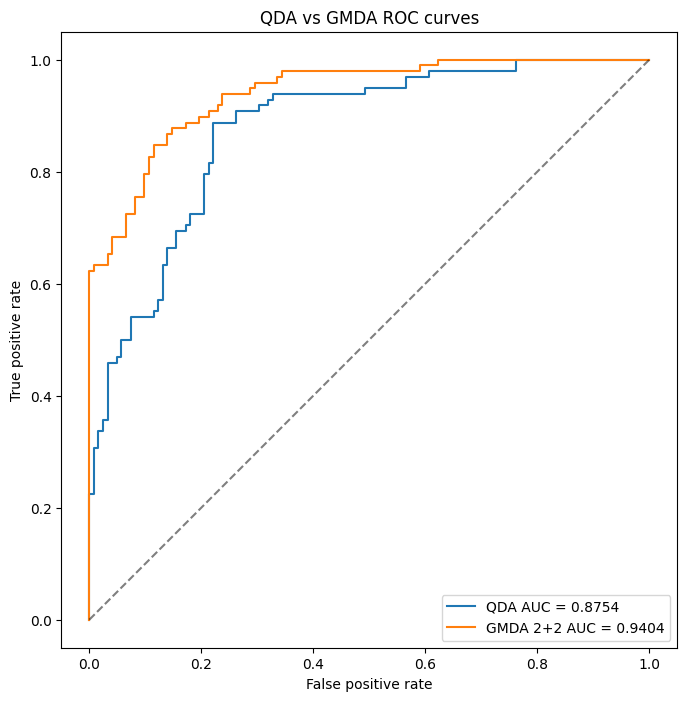

In [7]:
def make_pdf(cmp):
    dists = [st.multivariate_normal(cmp.means_[i], cmp.covariances_[i]) for i in range(cmp.n_components)]

    def pdf(x):
        x = np.asarray(x)
        p = np.zeros(x.shape[0])
        for i in range(cmp.n_components):
            p += cmp.weights_[i] * dists[i].pdf(x)
        return p

    return pdf


def make_predict_proba(cmp0, cmp1, pi0=0.5, pi1=0.5):
    pdf0 = make_pdf(cmp0)
    pdf1 = make_pdf(cmp1)

    def p(x):
        p0 = pi0 * pdf0(x)
        p1 = pi1 * pdf1(x)
        return p1 / (p1 + p0)

    return p


gm0 = GaussianMixture(n_components=2, max_iter=100, tol=0.0001, reg_covar=1e-6, random_state=seed)
gm1 = GaussianMixture(n_components=2, max_iter=100, tol=0.0001, reg_covar=1e-6, random_state=seed)
gm0.fit(X_train[y_train == 0])
gm1.fit(X_train[y_train == 1])

pi1 = y_train.mean()
pi0 = 1.0 - pi1
mgda = make_predict_proba(gm0, gm1, pi0=pi0, pi1=pi1)
mgda_test_proba = mgda(X_test)
mgda_test_pred = (mgda_test_proba > 0.5).astype(int)
mgda_auc = roc_auc_score(y_test, mgda_test_proba)
mgda_fprs, mgda_tprs, mgda_thds = roc_curve(y_test, mgda_test_proba)

print('GMDA confusion matrix, normalized by true class:')
print(confusion_matrix(y_test, mgda_test_pred, normalize='true'))
print(f'GMDA ROC AUC: {mgda_auc:.4f}')

fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, mgda_test_pred, normalize='true', values_format='.3f', ax=ax, colorbar=False
)
ax.set_title('GMDA test confusion matrix')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(qda_fprs, qda_tprs, label=f'QDA AUC = {qda_auc:.4f}')
ax.plot(mgda_fprs, mgda_tprs, label=f'GMDA 2+2 AUC = {mgda_auc:.4f}')
ax.plot([0, 1], [0, 1], linestyle='--', color='black', alpha=0.5)
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('QDA vs GMDA ROC curves')
ax.legend()
plt.show()


In [8]:
mgda_test_proba[:10]


array([2.99872623e-02, 4.18597038e-01, 1.38068875e-01, 2.40377005e-06,
       3.16570326e-01, 7.42669232e-01, 1.64207439e-01, 1.09621838e-01,
       3.66302901e-02, 2.31826058e-05])